In [1]:
import pwr_rei_template as pwr
import openmc
import openmc.deplete
import numpy as np
import copy
import pickle as pkl

"""
Depletion scheme for explicit euler. Meant to just get cross sections at the very end for reuse later.
"""

class Regression():
  def __init__(self):
    pass

  def tally_by_gen(self, res: dict):
    """does a quick cleanup after running transport"""
    theLength = res[0].__len__()
    shape0 = np.zeros(theLength)
    d = {}
    """nice little function to get tallies by gen"""
    for key in res.keys():
      shape1 = np.array([ this[:,:,1][0][0] for this in res[key][0:theLength] ])
      shape = shape1 - shape0
      d[key] = shape
      # advance
      shape0 = shape1
    return d

  def normalize_res(self, res: dict, val: float):
    """normalizes res dictionary to some value"""
    for key in res.keys():
      the_sum = np.sum(res[key])
      if the_sum == 0:
        res[key] = res[key]
      else:
        res[key] = res[key] / the_sum * val
    return res

  def _get_vij(self, N: int, start: int, F: list, I: list,
              i: int, j: int, f: int):
    Vij = 0.0
    for k in range(start,start+N):
      Vij += (F[i][k][f] - I[i][f])*(F[j][k][f] - I[j][f]) / (N-1)
    return Vij

  def get_new_I(self, N: int, start: int,
                F: list, I: list,
                f: int):
    """
    Parameters
    ==========
    N : int
      number active histories

    start : int
      starting aka nSkipped

    F : list
      list of res dicts (F1, F2, F3, ...)

    I : list
      list of final I values (normalized?)

    f : int
      tally id number to operate on.

    Returns
    =======
    new_I : float
      the new value of I corresponding to tally id f
    coeff : float
      the correlation coefficient

    """
    n = len(F)
    V = np.zeros((n,n))
    for i in range(n):
      for j in range(n):
        V[i,j] = self._get_vij(N=N, start=start, F=F, I=I, i=i, j=j, f=f) # returns vectror of Vij where each index is a fuel zone

    print("the matrix V is")
    print(V)
    if n == 2:
      # print correlation a and b
      coeff = V[1,0]/V[0,0]**0.5/V[1,1]**0.5
      print("the correlation coeff = ", coeff)
    else:
      coeff = 0
    the_I = np.array([[this[f] for this in I]]).transpose() # col vec of my best estimates.
    X = np.ones((n,1)) # col vec of ones.
    M = np.linalg.inv(X.transpose() @ np.linalg.inv(V) @ X) @ X.transpose() @ np.linalg.inv(V)
    print("\nThe matrix is: ", M, "\n")
    new_I = M @ the_I
    return new_I, coeff

def run_transport_for_chain(model: openmc.Model, chain_file: str):
  """runs an openmc transport calculation for getting the depletion chain"""
  able_mats = depletable_mats_from_model(model) # get the depletable materials (so we can tally)
  fluxes, micros = openmc.deplete.get_microxs_and_flux(model, able_mats, chain_file=chain_file)
  return fluxes, micros

def run_transport(model: openmc.Model, power_tally_ids: list):
  """runs an openmc transport calculation while doing batch-by-patch tallies"""
  model.export_to_xml()
  res = {} # contains/stores power tally ids and stuff like that.
  settings = model.settings

  openmc.lib.init()
  openmc.lib.simulation_init()
  for b in range(settings.batches):
    tallies = [openmc.lib.tallies[the_id] for the_id in power_tally_ids]
    openmc.lib.next_batch()
    results = [tally.results for tally in tallies]
    res[b] = copy.deepcopy(results)
  openmc.lib.simulation_finalize()
  openmc.lib.finalize()
  return res

def depletable_mats_from_model(model: openmc.Model) -> openmc.Materials:
  """get depletable materials as openmc.Materials object"""
  depletable_mats = []
  for this in model.materials:
    if this.depletable:
      depletable_mats.append(this)
  depletable_mats = openmc.Materials(depletable_mats)
  return depletable_mats

def get_nuclides_for_transport(chain_file: str, model: openmc.Model):
  from openmc.deplete.coupled_operator import _find_cross_sections, _get_nuclides_with_data
  from openmc.deplete.chain import Chain
  chain = Chain.from_xml(chain_file)
  cross_sections = _find_cross_sections(model)
  nuclides_with_data = _get_nuclides_with_data(cross_sections)
  nuclides = [nuc.name for nuc in chain.nuclides
              if nuc.name in nuclides_with_data]
  return nuclides

def make_transport_material_library(output_name: str, model: openmc.Model, chain_file: str):
  """
  Function to take in a model, chain, and reults file.

  Updates the model.materials to be the transport materials
  with the latest results from results file. Inline modification

  Only considers transport nuclides though.
  """

  # Make transport material library.

  results = openmc.deplete.Results(output_name)
  transport_mats = []

  # Depletables
  trans_nuc_list = get_nuclides_for_transport(chain_file=chain_file, model=model)
  for mat in model.materials:
    if not mat.depletable:
      continue # skip if not depletable

    # Make a new material for the depletables
    new_mat = openmc.Material(mat.id, mat.name, temperature=mat.temperature)
    new_mat.volume = mat.volume
    new_mat.depletable = True
    for nuc in trans_nuc_list:
      perc = results.get_atoms(mat=mat, nuc=nuc, nuc_units='atom/b-cm')[-1][-1]
      new_mat.add_nuclide(nuclide=nuc, percent=perc, percent_type='ao')
      new_mat.set_density(units='sum')
    transport_mats.append(new_mat)

  # Nondepletables, can just append what we have already
  for mat in model.materials:
    if not mat.depletable:
      transport_mats.append(mat)

  new_lib = openmc.Materials(transport_mats)
  # new_lib.export_to_xml()
  model.materials = new_lib

def get_depletion_materials_from_results_EOS(output_name: str, model: openmc.Model):
  """
  Function for getting materials for depletion EOS values (or BOS for the next step)
  Returns a list of materials marked depletable
  with full depletion chain.

  No inline modification of models object.
  """
  results = openmc.deplete.Results(output_name)
  depletion_mat_list = []
  for mat in model.materials:
    if mat.depletable:
      eos_mat = results[-1].get_material(str(mat.id))
      depletion_mat_list.append(eos_mat)
  return openmc.Materials(depletion_mat_list)



[ 11.4375  34.3125  57.1875  80.0625 102.9375 125.8125 148.6875 171.5625
 194.4375 217.3125 240.1875 263.0625 285.9375 308.8125 331.6875 354.5625]


/home/jonathon/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/stats/multivariate.py:829: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


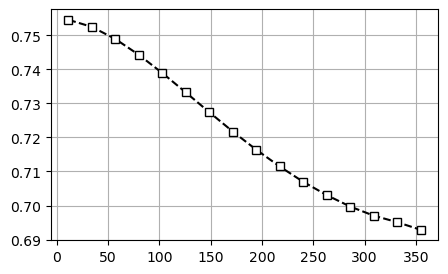

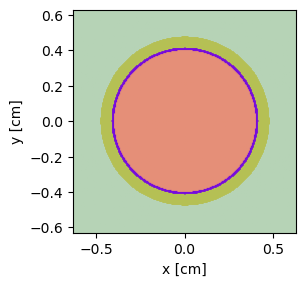

In [2]:
"""some random settings"""
fuel_r=0.3975
power_density = 104
power = power_density * 366  * np.pi * fuel_r**2
dt = [0.5, 1, 1.5, 2, 5, 10, 20] # up to 20 days
iterations = 1 # number of iterations we run (so +1 to this for total # transports)
Nstart = 1
Nactive = 9

"""get the model"""
model = pwr.get_model()
chain_file = '../chain_casl_pwr.xml'

"""regression class"""
regr =  Regression()

"""run explicit euler depletion scheme"""
depletion_materials = depletable_mats_from_model(model=model) # get from starting model
depl_id_list = [this.id for this in depletion_materials]

In [3]:
"""T0 transport and get fluxes"""
d = run_transport(model=model, power_tally_ids=depl_id_list) ## this one for res tracking...
res = regr.tally_by_gen(res=d)
res_normd = regr.normalize_res(res=res, val=1.0)
last_shape = res_normd[max(list(res_normd.keys()))]
fluxes = last_shape # todo might have to do something to this shape but just get the last one is ok.
_fakefluxes, micro_xs = run_transport_for_chain(model=model, chain_file=chain_file) # todo load reference xs here instead

for idx, this_dt in enumerate(dt):
  res_list = []
  I = []
  for ni in range(iterations+1):
    """Start w/ predicting forward in time with most recent fluxes"""
    # Deplete (operator setup and then deplete)
    output_name = f"depl_step_s{idx}_i{ni}.h5"
    print("Now depleting with flux =", fluxes)
    op = openmc.deplete.IndependentOperator(depletion_materials, fluxes, micro_xs, chain_file=chain_file)
    openmc.deplete.PredictorIntegrator(op, timesteps=[this_dt], power=power, timestep_units='d').integrate(path=output_name)

    # Now update the transport materials (inline modify model.materials)
    make_transport_material_library(output_name=output_name, model=model, chain_file=chain_file)
    d = run_transport(model=model, power_tally_ids=depl_id_list) ## this one for res tracking...
    res =  regr.tally_by_gen(res=d)
    res_normd = regr.normalize_res(res=res, val=1.0)
    last_shape = res_normd[max(list(res_normd.keys()))]
    fluxes = last_shape # todo might have to do something to this shape but just get the last one is ok.
    I.append(copy.deepcopy(fluxes))
    res_list.append(res_normd)

    # Corrector fluxes or keep them as is (correct if ni is above 0)
    if ni > 0:
      fluxes = []
      for f in depl_id_list: # go thorugh fList and get all the newly predicted fluxes.. note that tally id's have same ids as depl materials
        flux_f = 1# ### USE THIS ONE ->## regr.get_new_I(N=Nactive, start=Nstart, F=res_list, I=I, f=f)
        fluxes.append(flux_f)
    else:
      fluxes = fluxes

  # Now make the depletion materials BOS for the next depletion step...
  depletion_materials = get_depletion_materials_from_results_EOS(output_name=output_name, model=model)



                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Mo95 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo96 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo96.h5
 Reading Mo97 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo97.h5
 Reading Mo98 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo98.h5
 Reading Mo99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo99.h5
 Reading Mo100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo100.h5
 Reading Tc99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tc99.h5
 Reading Ru100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru100.h5
 Reading Ru101 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru101.h5
 Reading Ru102 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru102.h5
 Reading Ru103 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru103.h5
 Reading Ru104 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru104.h5
 Reading Ru105 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/ne

 Reading Xe136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Xe136.h5
 Reading Cs133 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs133.h5
 Reading Cs134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs134.h5
 Reading Cs135 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs135.h5
 Reading Cs136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs136.h5
 Reading Cs137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La139 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ce140.h5
 Reading Ce141 from /home/jonathon/openmc_xs/endfb-v

 Reading Gd154 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy162.h5
 Reading Dy163 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy163.h5
 Reading Dy164 from /home/jonathon/openmc_xs/endfb-v

 Reading Mo95 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo96 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo96.h5
 Reading Mo97 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo97.h5
 Reading Mo98 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo98.h5
 Reading Mo99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo99.h5
 Reading Mo100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo100.h5
 Reading Tc99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tc99.h5
 Reading Ru100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru100.h5
 Reading Ru101 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru101.h5
 Reading Ru102 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru102.h5
 Reading Ru103 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru103.h5
 Reading Ru104 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru104.h5
 Reading Ru105 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/ne

...

 Reading Xe136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Xe136.h5
 Reading Cs133 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs133.h5
 Reading Cs134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs134.h5
 Reading Cs135 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs135.h5
 Reading Cs136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs136.h5
 Reading Cs137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La139 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ce140.h5
 Reading Ce141 from /home/jonathon/openmc_xs/endfb-v

 Reading Gd154 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy162.h5
 Reading Dy163 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy163.h5
 Reading Dy164 from /home/jonathon/openmc_xs/endfb-v

 Reading Mo95 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo96 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo96.h5
 Reading Mo97 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo97.h5
 Reading Mo98 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo98.h5
 Reading Mo99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo99.h5
 Reading Mo100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Mo100.h5
 Reading Tc99 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tc99.h5
 Reading Ru100 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru100.h5
 Reading Ru101 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru101.h5
 Reading Ru102 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru102.h5
 Reading Ru103 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru103.h5
 Reading Ru104 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ru104.h5
 Reading Ru105 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/ne

 Reading Xe136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Xe136.h5
 Reading Cs133 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs133.h5
 Reading Cs134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs134.h5
 Reading Cs135 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs135.h5
 Reading Cs136 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs136.h5
 Reading Cs137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba134 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba137 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La139 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce140 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Ce140.h5
 Reading Ce141 from /home/jonathon/openmc_xs/endfb-v

 Reading Gd152 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd152.h5
 Reading Gd154 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy160 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from /home/jonathon/openmc_xs/endfb-vii.1-hdf5/neutron/Dy162.h5
 Reading Dy163 from /home/jonathon/openmc_xs/endfb-v